In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10,CIFAR100


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform = transforms.Compose([
    transforms.Resize([224,224]),
    transforms.ToTensor()
])          


In [3]:
cifar100_train = CIFAR100(root='./data', train=True, download=True, transform=transform)
cifar100_test = CIFAR100(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
model_algo="alexnet"

In [5]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [6]:
images=CifarDataset(cifar100_train)
generator = torch.Generator()
generator.manual_seed(125)

size = len(images)
valid_size = int(0.2 * size)

train_size = int(size -valid_size)

trainset,validset = random_split(images, (train_size, valid_size), generator=generator)

In [7]:
valid_size

10000

In [8]:
train_size

40000

In [9]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=2.5702907291412354,train_accu=0.34355
Epoch=0,valid_loss=2.6931522579193117,valid_accu=0.3195
0
Epoch=1,train_loss=1.7716943727493286,train_accu=0.5216
Epoch=1,valid_loss=1.9564241230010986,valid_accu=0.4785
0
Epoch=2,train_loss=1.469070266199112,train_accu=0.60285
Epoch=2,valid_loss=1.7373742948532105,valid_accu=0.5267
0
Epoch=3,train_loss=1.2575645993709563,train_accu=0.651125
Epoch=3,valid_loss=1.6142866565704346,valid_accu=0.5558
0
Epoch=4,train_loss=1.027734686756134,train_accu=0.70875
Epoch=4,valid_loss=1.4548975048065185,valid_accu=0.5887
0
Epoch=5,train_loss=0.9645783455133438,train_accu=0.726925
Epoch=5,valid_loss=1.4603315729141235,valid_accu=0.5935
0
Epoch=6,train_loss=0.7957458126783371,train_accu=0.769075
Epoch=6,valid_loss=1.3781296854019165,valid_accu=0.6146
0
Epoch=7,train_loss=0.7501469801664352,train_accu=0.796
Epoch=7,valid_loss=1.35863791179657,valid_accu=0.6195
0
Epoch=8,train_loss=0.6121835550665855,train_accu=0.827125
Epoch=8,valid_loss=1.31314

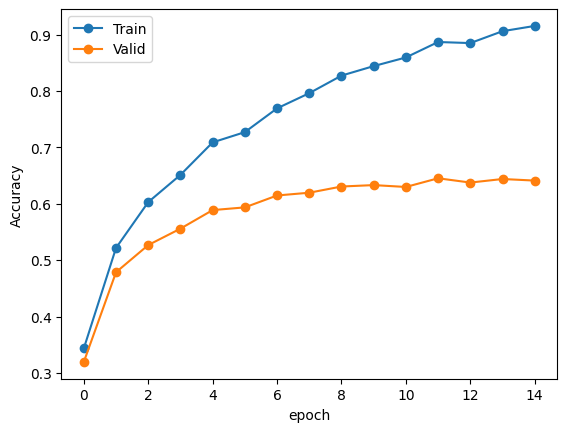

In [10]:
model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
# model_0 = torch.load(f'model_{model_algo}_0_5.pth')

In [11]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.4202361589550972, 0.8867)

In [12]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(1.2882944053649903, 0.6451)

In [13]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [14]:
each_accu=p
each_accu

apple            0.955000
aquarium_fish    0.974937
baby             0.788114
bear             0.813776
beaver           0.789216
                   ...   
whale            0.883610
willow_tree      0.835411
wolf             0.848329
woman            0.707317
worm             0.846154
Length: 100, dtype: float64

In [15]:
each_f1=2*p*r/(p+r)
each_f1

apple            0.962217
aquarium_fish    0.965261
baby             0.825440
bear             0.809645
beaver           0.781553
                   ...   
whale            0.876325
willow_tree      0.791027
wolf             0.905350
woman            0.758170
worm             0.889179
Length: 100, dtype: float64

In [16]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('TandF')

if(split_mode[0]=='classf1'):
    targetF=[x  for x in each_f1.nsmallest(split_mode[1]).index.map(trainset.dataset.classess)]
    split=(split_mode[0],targetF)
elif(split_mode[0]=='classaccu'):
    targetF=[x  for x in each_accu.nsmallest(split_mode[1]).index.map(trainset.dataset.classess)]
    split=(split_mode[0],targetF)
else:
    split=split_mode

indexF,indexT=split_data(model_0,train_dl,split)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)

Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)

len(indexF),len(indexT)

(4532, 35468)

In [17]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split)
len(indexF_v),len(indexT_v)

(3549, 6451)

In [18]:
# d_data,d_target=decision_split(train_dl,model_0)
# d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [19]:
# decisionset=DecisionDataset(d_data,d_target)
# decisionset_v=DecisionDataset(d_v_data,d_v_target)

Epoch=0,train_loss=0.3020611119508743,train_accu=0.8867
Epoch=0,valid_loss=0.8127169619560242,valid_accu=0.6451
0
Epoch=1,train_loss=0.2967641451060772,train_accu=0.8868
Epoch=1,valid_loss=0.7334530618667603,valid_accu=0.6453
0
Epoch=2,train_loss=0.28133236087560654,train_accu=0.887275
Epoch=2,valid_loss=0.7879988187789917,valid_accu=0.6451
Epoch=3,train_loss=0.2671581905066967,train_accu=0.88865
Epoch=3,valid_loss=0.7890212326049805,valid_accu=0.6455
0
Epoch=4,train_loss=0.2659771004498005,train_accu=0.8923
Epoch=4,valid_loss=0.7367484866142273,valid_accu=0.6437
Epoch=5,train_loss=0.2415340439736843,train_accu=0.8944
Epoch=5,valid_loss=0.7671976943016052,valid_accu=0.6452
Epoch=6,train_loss=0.2243666516005993,train_accu=0.896925
Epoch=6,valid_loss=0.8421059193611145,valid_accu=0.6456
0
Epoch=7,train_loss=0.21311074154376983,train_accu=0.916375
Epoch=7,valid_loss=0.7954839632987976,valid_accu=0.6486
0
Epoch=8,train_loss=0.19381321541666985,train_accu=0.921875
Epoch=8,valid_loss=0.83127

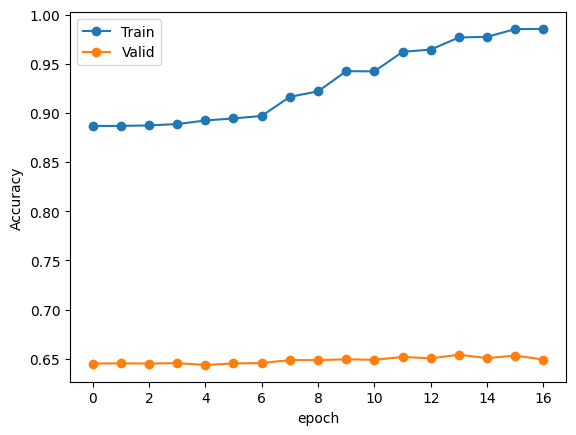

In [20]:
# from torchsampler import ImbalancedDatasetSampler
# decision_dl = DataLoader(decisionset, batch_size=32)
# decision_dl = DataLoader(decisionset, batch_size=32,sampler=ImbalancedDatasetSampler(decisionset))
# decision_v_dl = DataLoader(decisionset_v, batch_size=32)
# train_dl=DataLoader(trainset, batch_size=32,sampler=ImbalancedDatasetSampler(trainset))
model_decision=model_train(model_algo,train_dl,valid_dl,"decision",70,model_0=model_0)

In [21]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)

Fdl_v=DataLoader(Fdataset_v, shuffle=False, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=False, batch_size=batch_size)

Epoch=0,train_loss=0.14753496341194713,train_accu=0.9785158452689748
Epoch=0,valid_loss=0.22336975494441533,valid_accu=0.9451247868547512
0
Epoch=1,train_loss=0.12056301217398058,train_accu=0.9837600090222172
Epoch=1,valid_loss=0.21226419820986575,valid_accu=0.9451247868547512
Epoch=2,train_loss=0.09895269398633073,train_accu=0.9892861170632683
Epoch=2,valid_loss=0.1944011023360211,valid_accu=0.9486901255619283
0
Epoch=3,train_loss=0.0877411794243018,train_accu=0.9905830607871885
Epoch=3,valid_loss=0.19322685804261364,valid_accu=0.9474500077507363
Epoch=4,train_loss=0.07492272727093978,train_accu=0.9934588925228375
Epoch=4,valid_loss=0.18548618542780304,valid_accu=0.9449697721283522
Epoch=5,train_loss=0.06445065763314427,train_accu=0.994671252960415
Epoch=5,valid_loss=0.18602385249845263,valid_accu=0.9446597426755542
3 Early stopping!


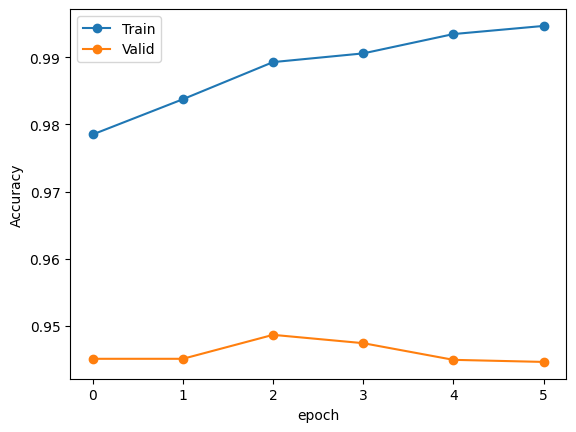

In [22]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70,model_0=model_0)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=1.4719404508240541,train_accu=0.5033097969991174
Epoch=0,valid_loss=2.756271892078966,valid_accu=0.17666948436179206
0
Epoch=1,train_loss=1.3307778399703993,train_accu=0.5906884377758164
Epoch=1,valid_loss=2.7071090577588546,valid_accu=0.17328825021132713
Epoch=2,train_loss=1.2064221512398041,train_accu=0.6434245366284201
Epoch=2,valid_loss=2.730521548261237,valid_accu=0.18878557340095803
0
Epoch=3,train_loss=1.0919170737371755,train_accu=0.6990291262135923
Epoch=3,valid_loss=2.7192544974082287,valid_accu=0.18653141730064807
Epoch=4,train_loss=0.9782294911403943,train_accu=0.7488967343336276
Epoch=4,valid_loss=2.7496159272181817,valid_accu=0.19611158072696533
0
Epoch=5,train_loss=0.8834394949890298,train_accu=0.7963371579876434
Epoch=5,valid_loss=2.7570581658520004,valid_accu=0.20061989292758522
0
Epoch=6,train_loss=0.7881911420653799,train_accu=0.8210503089143866
Epoch=6,valid_loss=2.780059350984605,valid_accu=0.20315581854043394
0
Epoch=7,train_loss=0.7139420997012

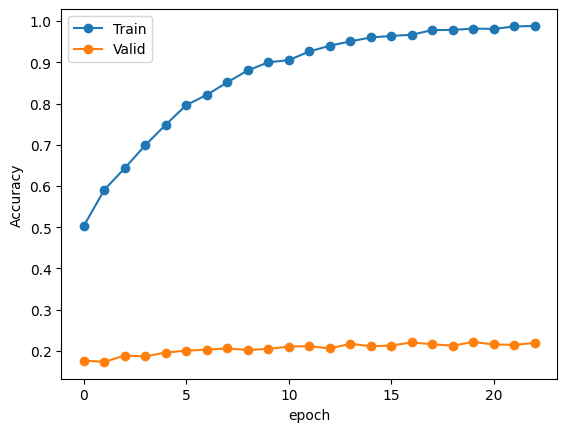

In [23]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70,model_0=model_0)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [24]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,train_dl,len(trainset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.12662055449783802, 0.97675)

In [25]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,valid_dl,len(validset),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.8911077987670899, 0.6541)

In [26]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.09895269396952555, 0.9892861170632683)

In [27]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.2049992338072801, 0.9819064430714917)

In [28]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.1944011023360211, 0.9486901255619283)

In [29]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(3.0461040634140226, 0.221752606367991)

In [30]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.1109678307697177, 0.98845, 4532)

In [31]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(1.2064704431533813, 0.6907, 3549)

In [32]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision,decision_mode='model')
total_train_loss,total_train_accu,sum_F,sum_T

(0.16079993771016599, 0.9709, 3770, 36230)

In [33]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision,decision_mode='model')
total_valid_loss,total_valid_accu,sum_F,sum_T

(1.3721653777122498, 0.6572, 300, 9700)

In [34]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [35]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_with_perfect_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'split_mode = {split}')
df

split_mode = TandF


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.420236,0.886700,1.288294,0.645100
1,Model_Decision,0.126621,0.976750,0.891108,0.654100
2,Model_T,0.098953,0.989286,0.194401,0.948690
3,Model_F,0.204999,0.981906,3.046104,0.221753
4,Total_Model,0.160800,0.970900,1.372165,0.657200
5,Total_Model_with_perfect_decision,0.110968,0.988450,1.206470,0.690700


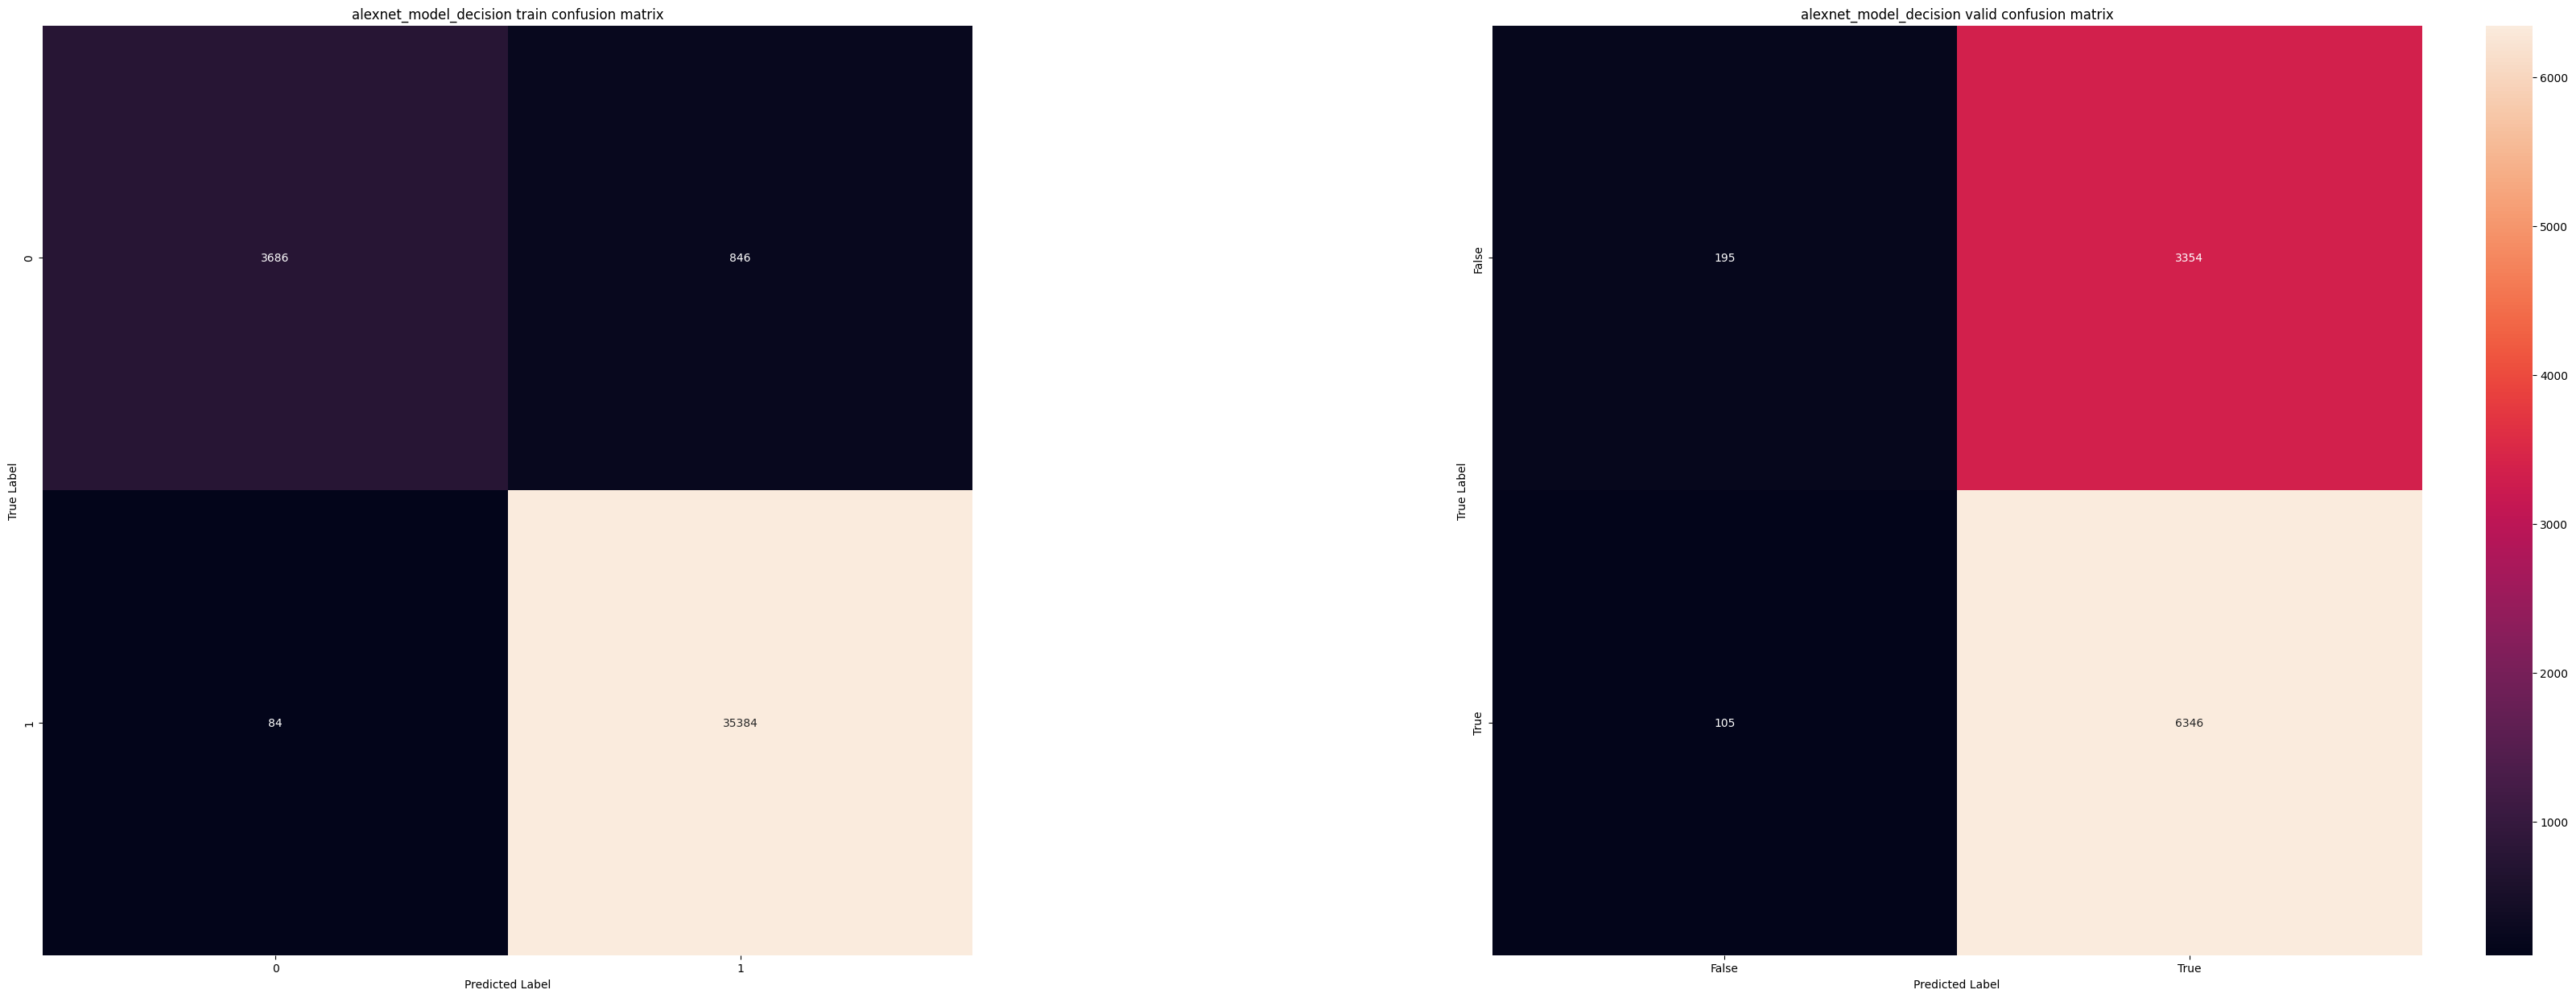

In [36]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

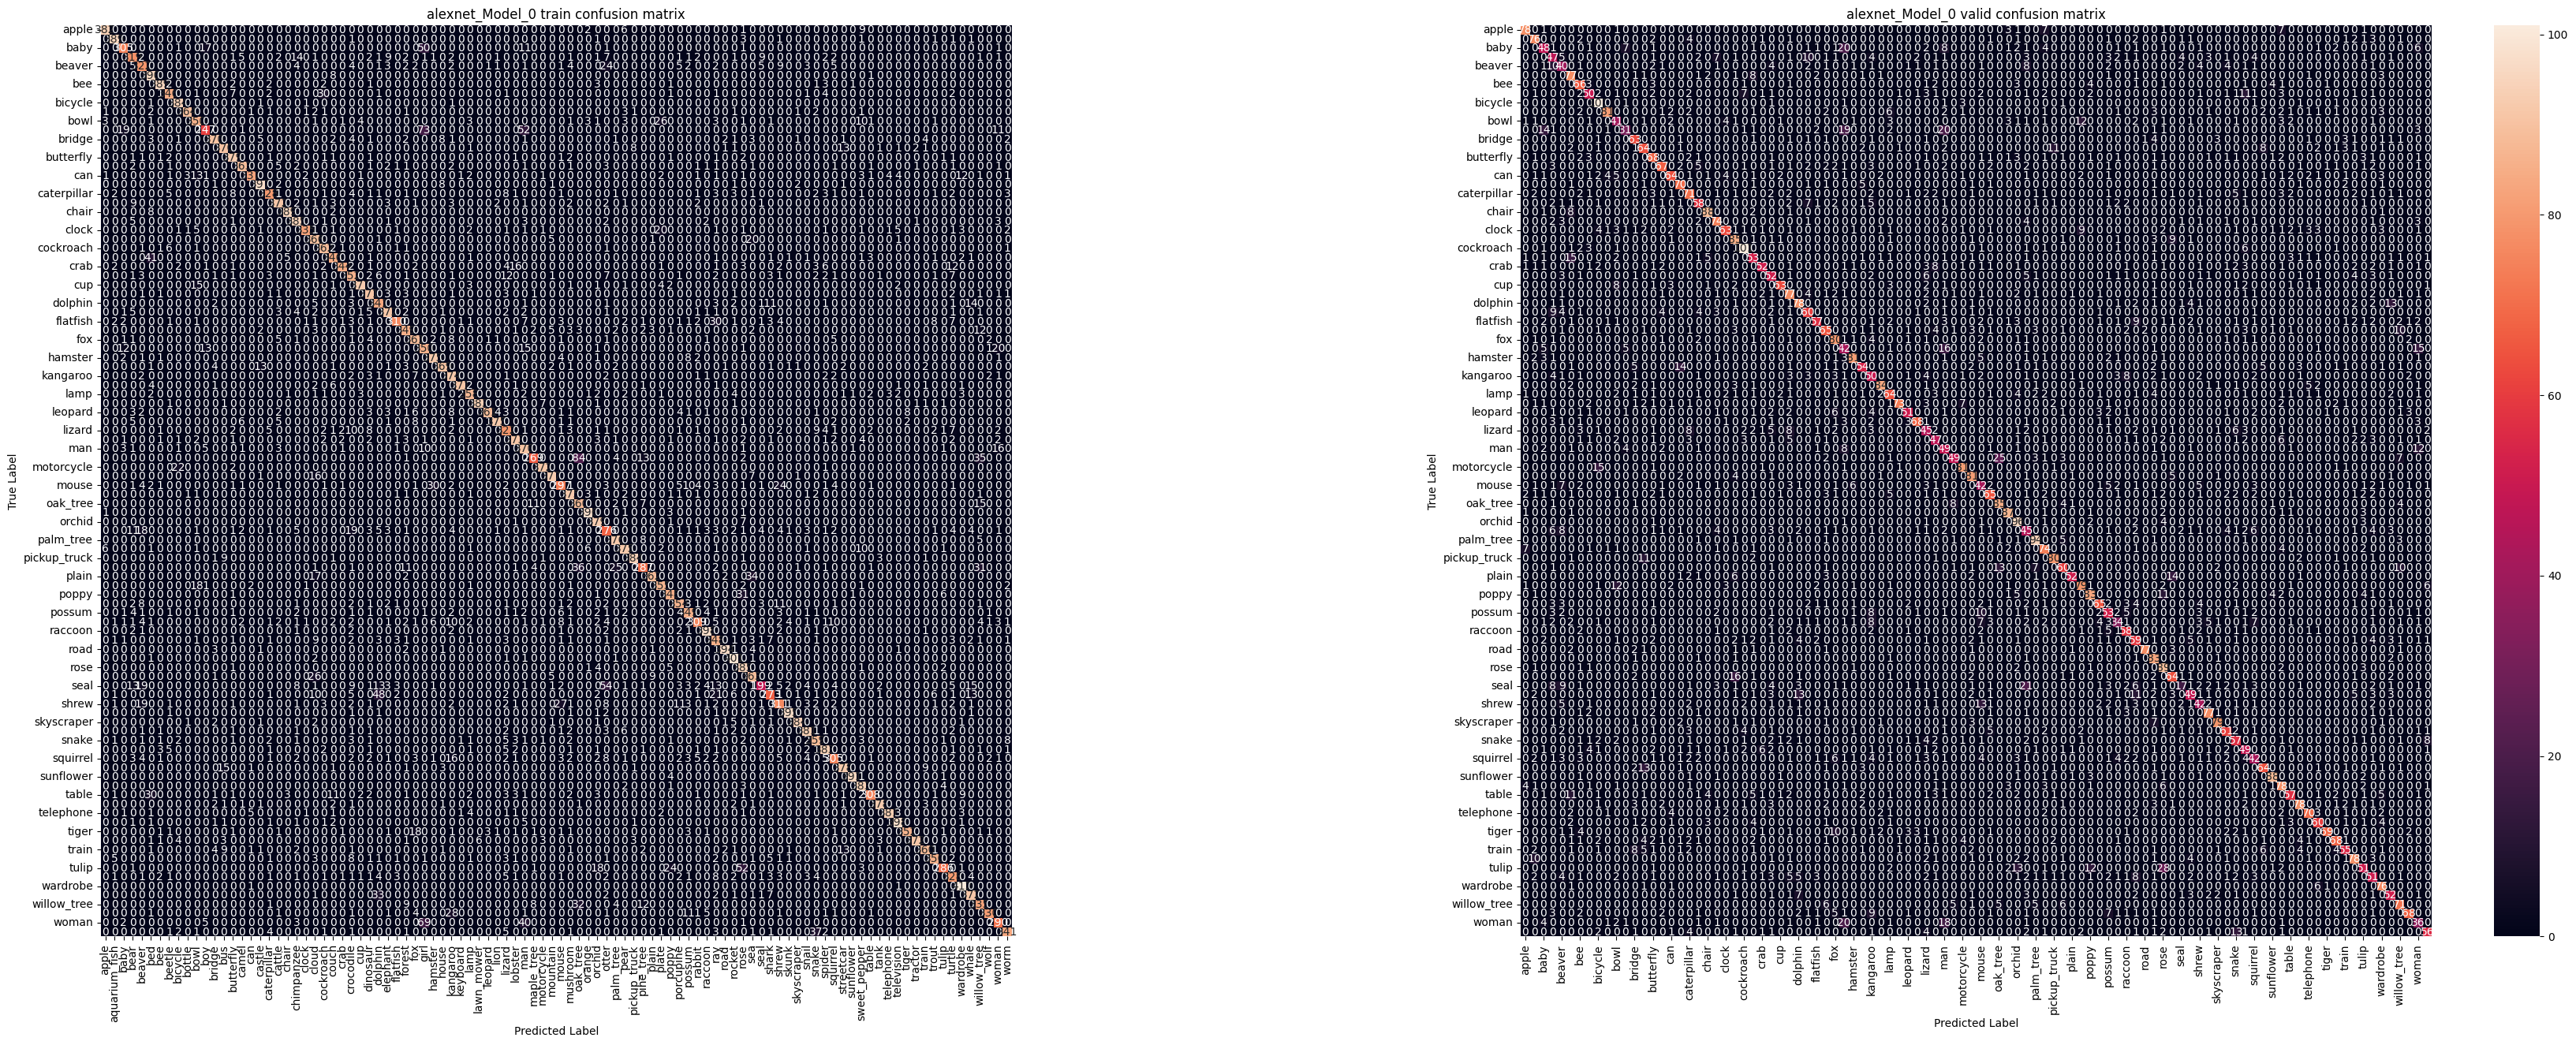

In [37]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

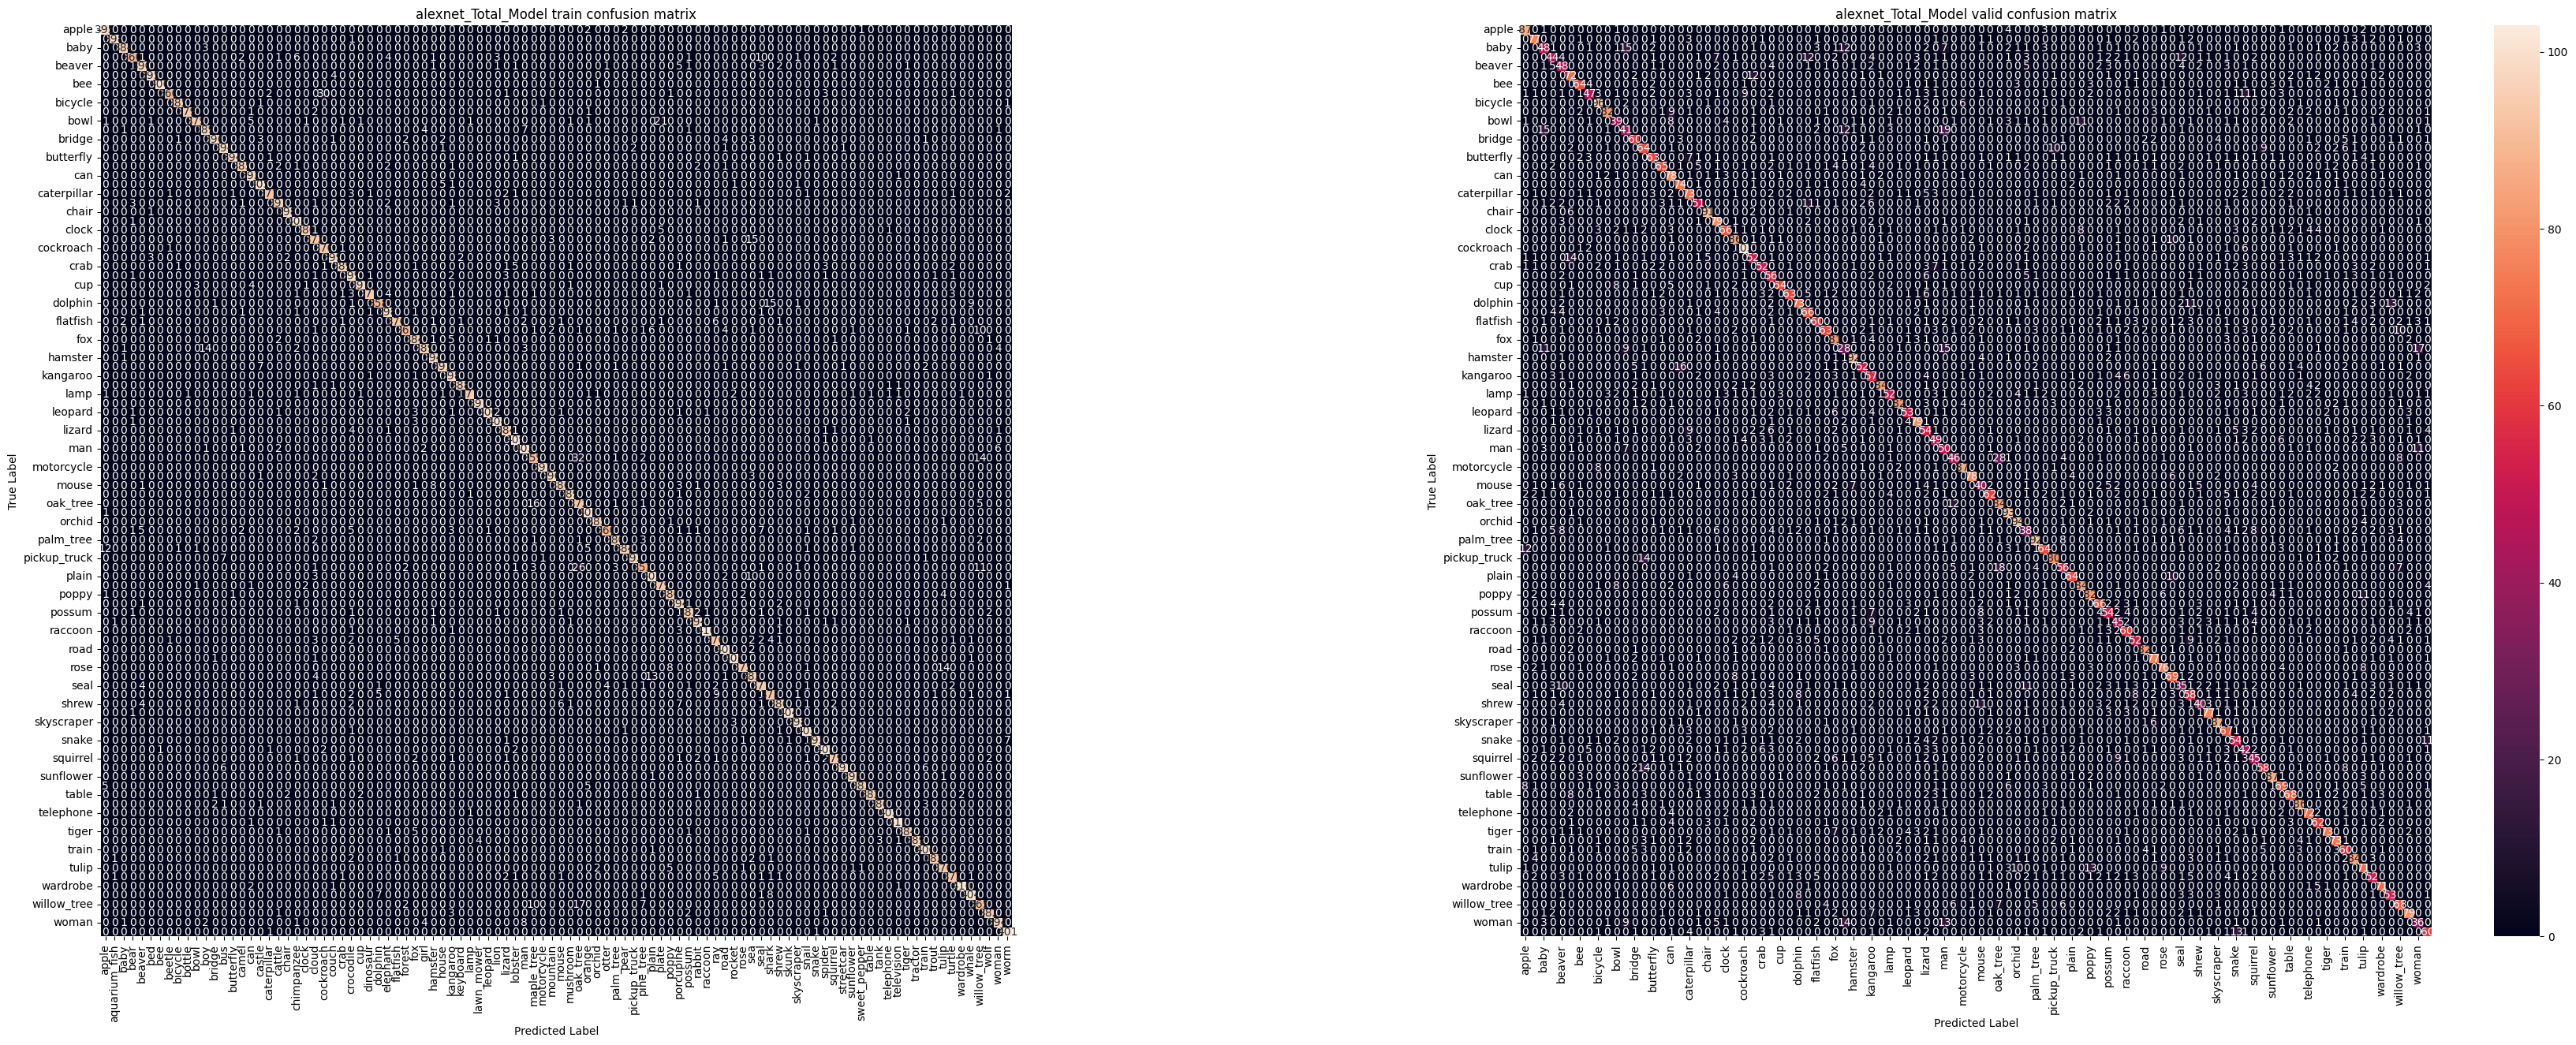

In [38]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

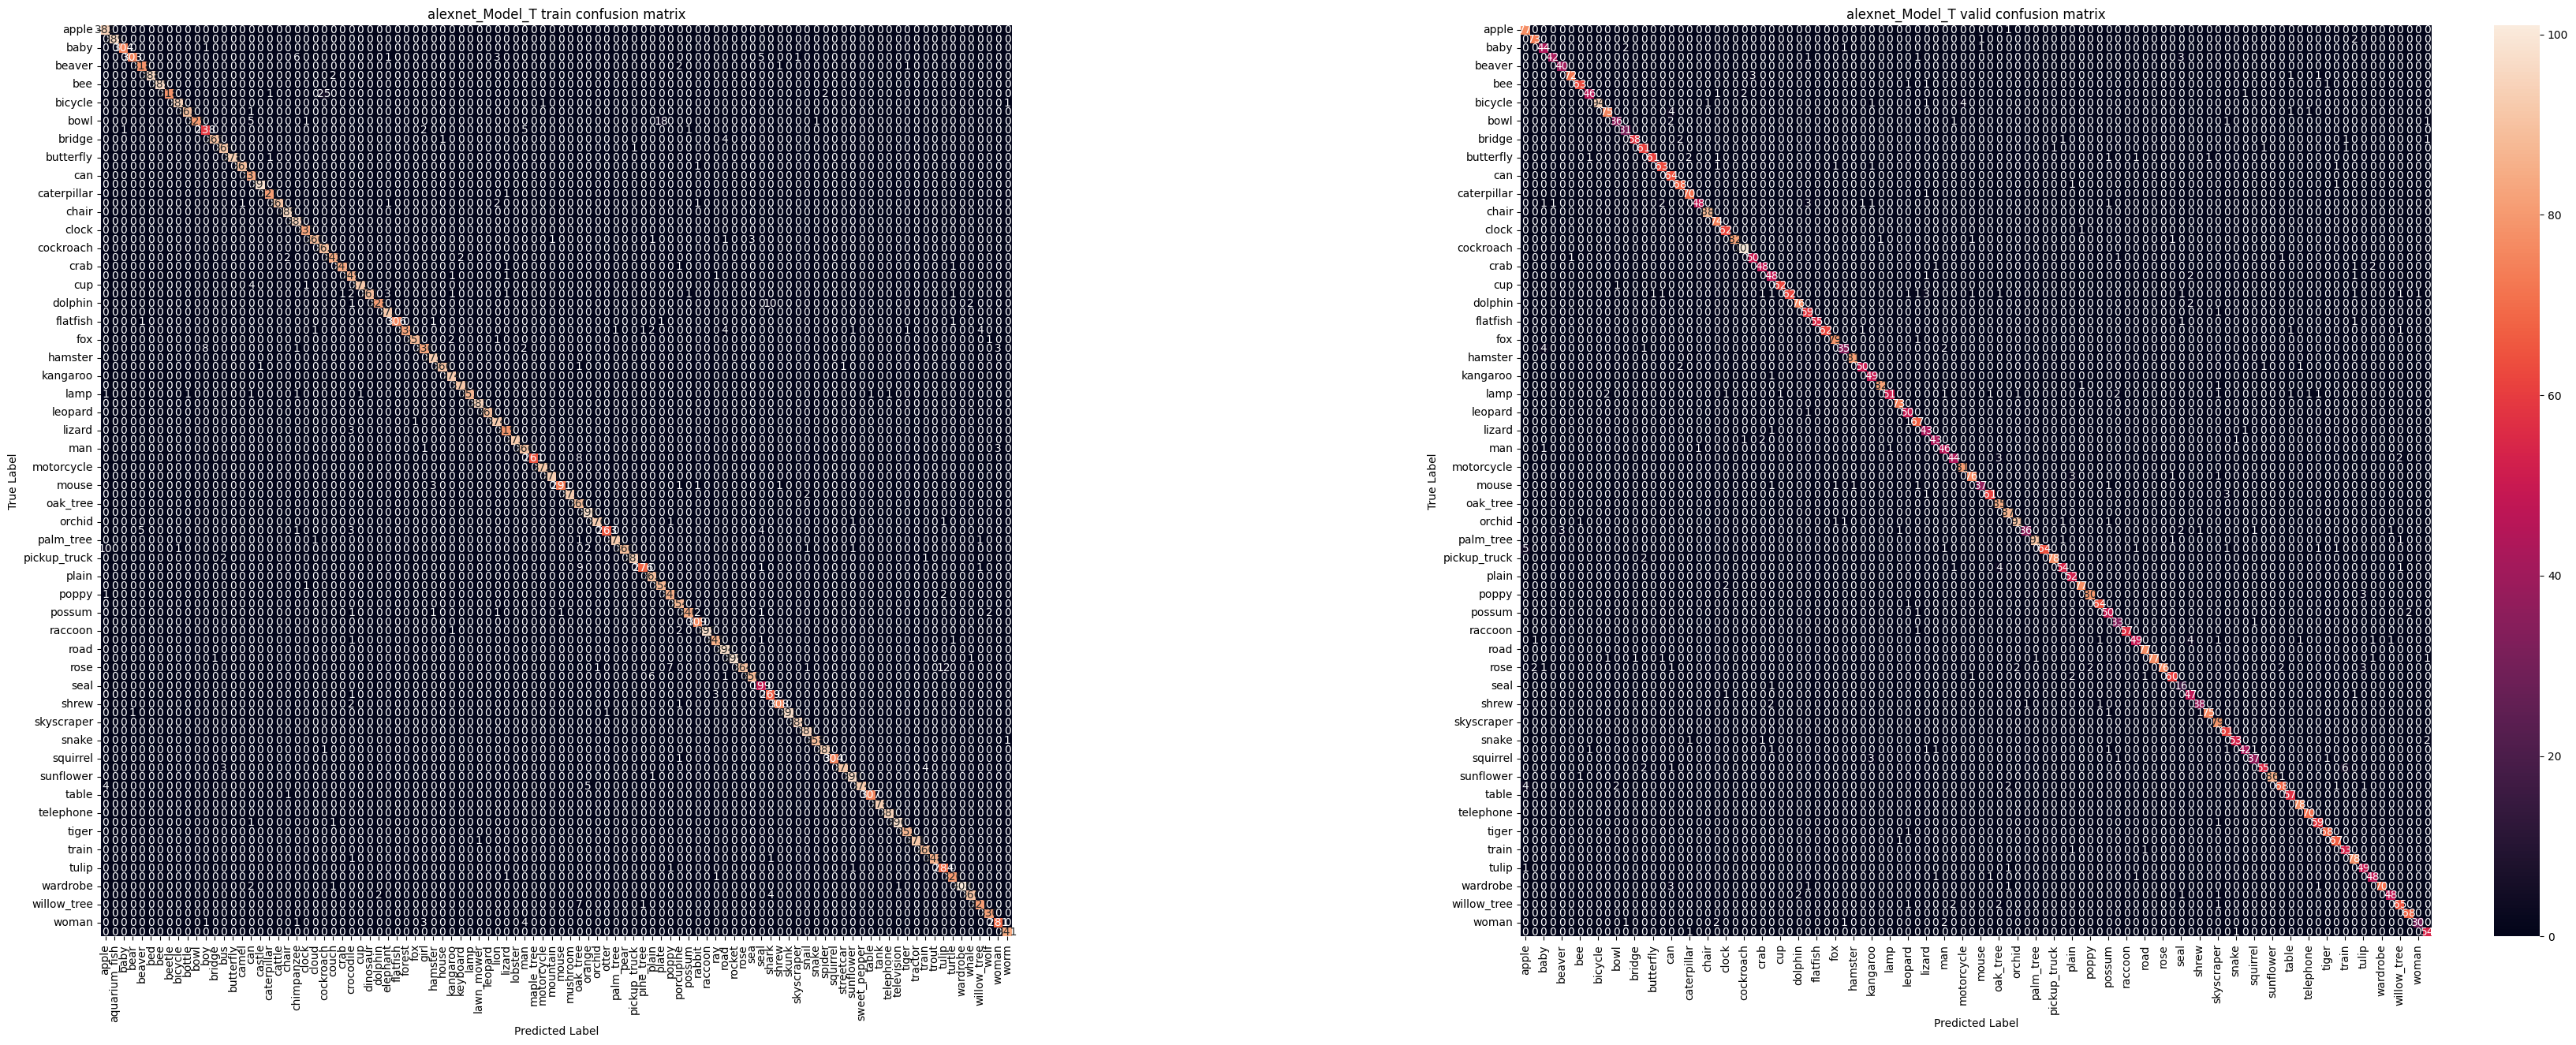

In [39]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

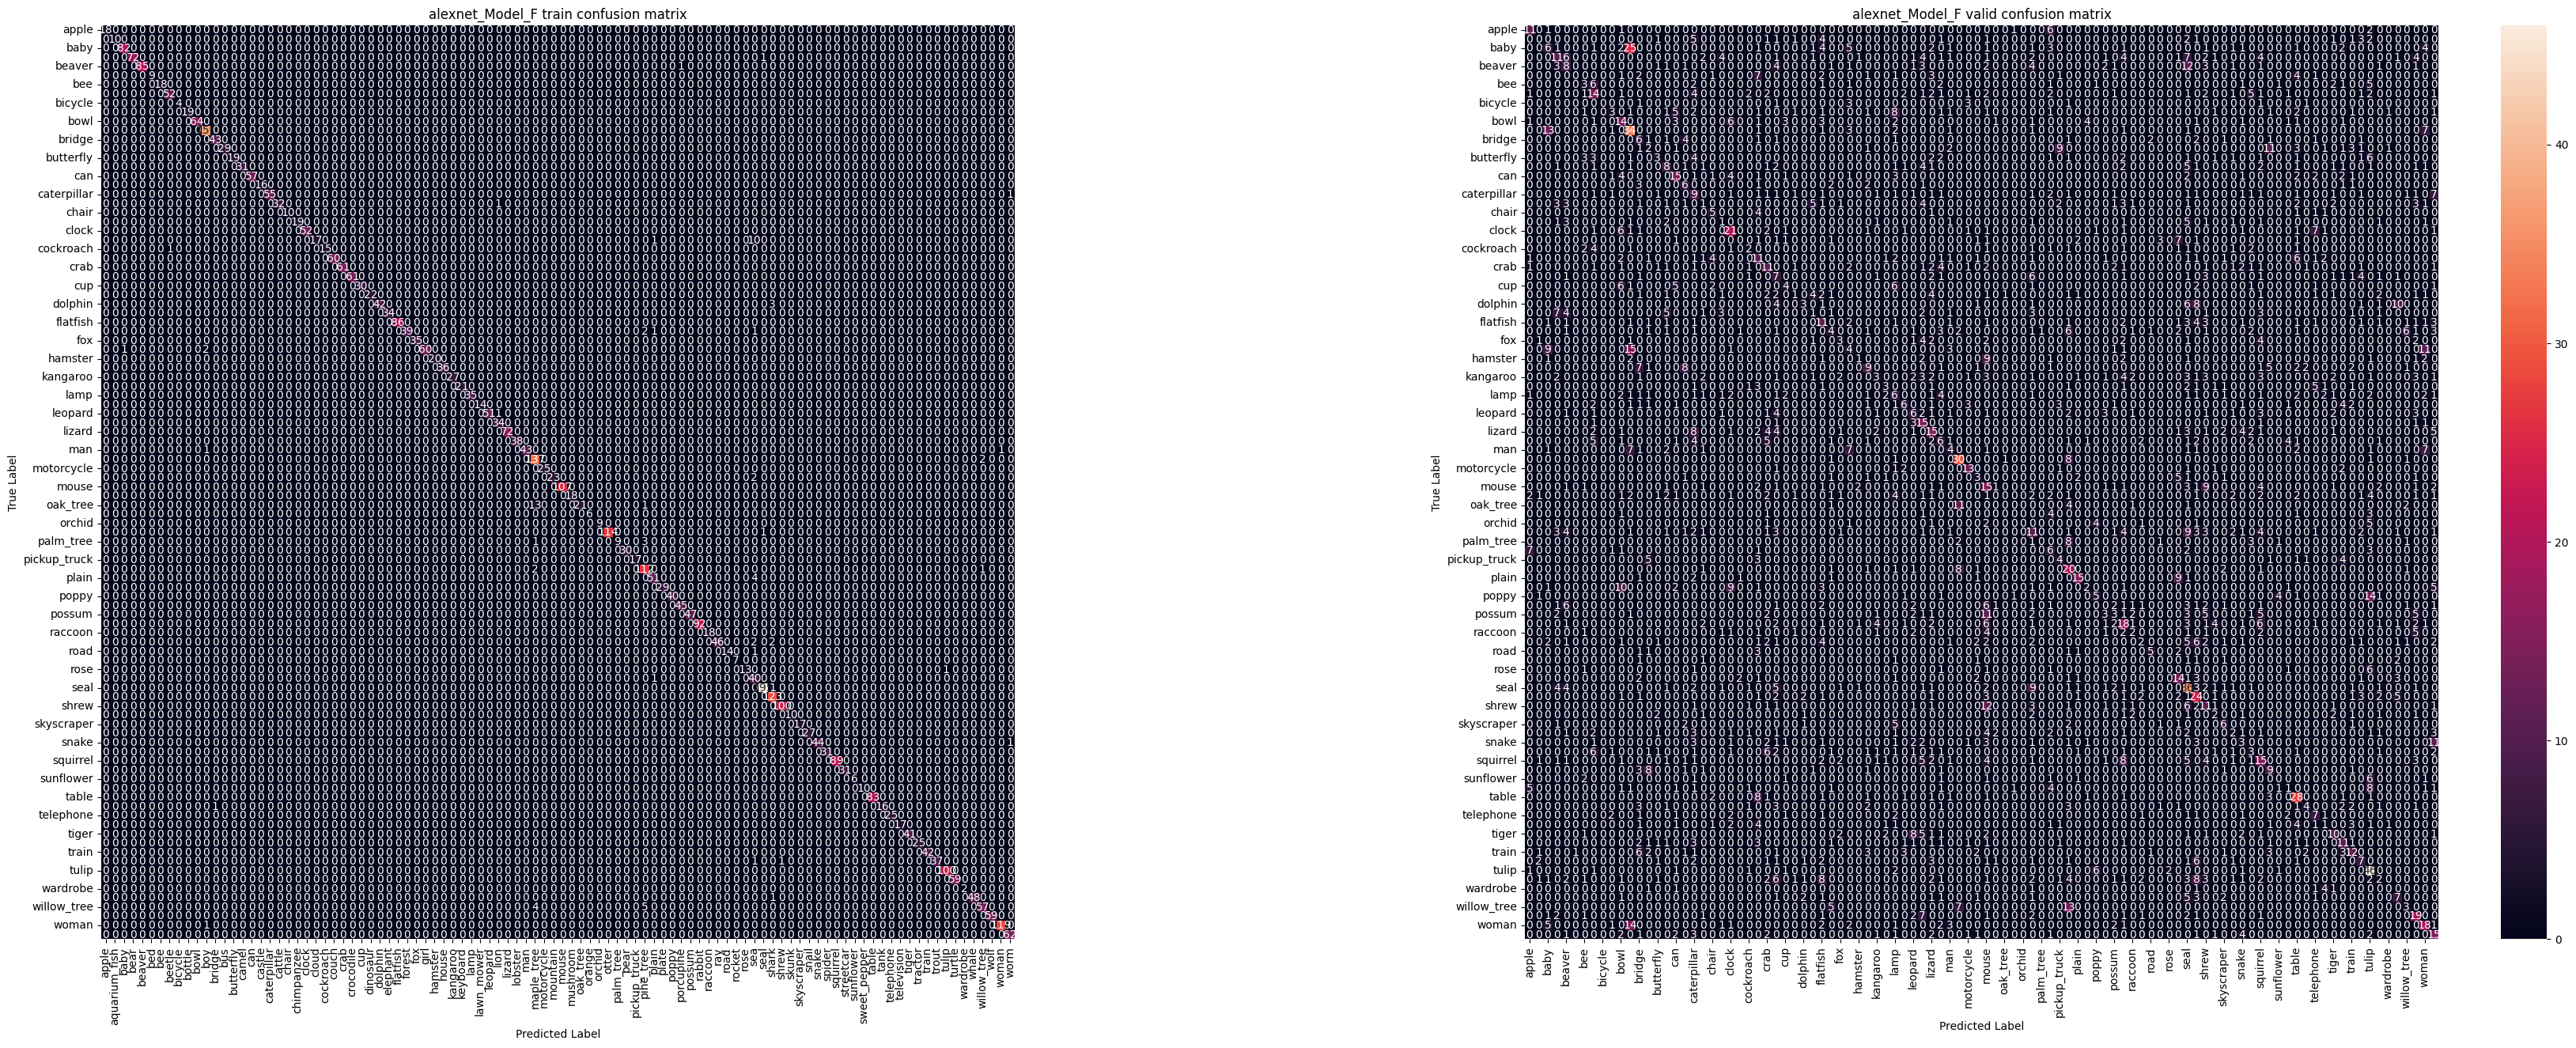

In [40]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [41]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,_,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [42]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,36693,0,0,0,0,0.999694,0.999948,0.995369,0.998809,True,True,True,True,True
1,11055,92,92,92,92,0.994970,0.948377,0.785403,0.923448,True,True,True,True,True
2,22380,16,16,16,16,0.942654,0.999461,0.990306,0.998984,True,True,True,True,True
3,16388,50,50,50,50,0.674091,0.886207,0.746183,0.988056,True,True,True,True,True
4,39840,14,14,14,14,0.998745,0.999956,0.999817,0.998768,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,21246,61,10,61,61,0.513825,0.990743,0.946728,0.967583,False,True,True,True,True
39996,15140,56,59,56,56,0.659529,0.828093,0.699888,0.593749,False,True,True,True,True
39997,31217,15,15,15,15,0.964499,0.951704,0.754028,0.901562,True,True,True,True,True
39998,19446,10,10,10,10,0.909884,0.991799,0.982475,0.982343,True,True,True,True,True


In [43]:
len(df_results[df_results['Decision']!=df_results['flag']])

930

In [44]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
11,46571,32,32,67,67,0.956519,0.734254,0.549710,0.644492,True,False,False,True,False
12,45329,62,62,62,70,0.971594,0.891997,0.537059,0.551507,True,True,False,True,False
79,11220,74,74,80,80,0.609820,0.417772,0.378082,0.559345,True,False,False,True,False
123,28270,55,55,55,55,0.327839,0.753648,0.471481,0.573669,True,True,True,False,True
141,1759,32,26,32,32,0.251419,0.288570,0.162984,0.514910,False,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39802,49244,67,67,23,23,0.742274,0.370194,0.369594,0.612883,True,False,False,True,False
39811,39728,42,42,34,34,0.894477,0.990756,0.854665,0.545831,True,False,False,True,False
39831,32372,59,59,33,33,0.736553,0.446754,0.379012,0.544765,True,False,False,True,False
39885,28977,97,97,38,38,0.854927,0.731525,0.332379,0.537233,True,False,False,True,False


In [45]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

47    41
59    39
73    28
55    26
96    23
      ..
86     1
48     1
8      1
87     1
75     1
Name: Target, Length: 99, dtype: int64

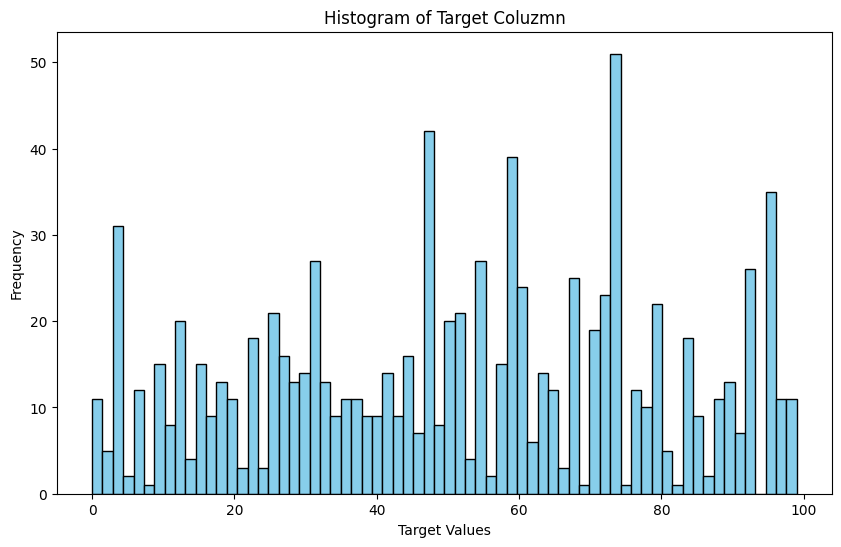

In [46]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Coluzmn')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [47]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,25700,41,41,41,41,0.999983,0.999999,0.999947,0.999986,True,True,True,True,True
1,14423,56,59,56,56,0.709114,0.996543,0.936095,0.986920,False,True,True,True,True
2,21078,18,18,18,18,0.878748,0.936672,0.850363,0.987319,True,True,True,True,True
3,17994,57,57,57,57,0.999628,0.999996,0.999972,0.999792,True,True,True,True,True
4,1281,52,96,52,52,0.417513,0.981804,0.821687,0.809119,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,22252,86,86,86,86,0.782870,0.960516,0.936073,0.974102,True,True,True,True,True
9996,46500,18,18,18,18,0.538093,0.587389,0.456167,0.503681,True,True,True,False,True
9997,37918,8,8,8,8,0.819775,1.000000,0.999992,0.998907,True,True,True,True,True
9998,32040,23,96,23,23,0.338386,0.891172,0.579205,0.611922,False,True,True,True,True


In [48]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
7,33893,97,43,43,6,0.910116,0.653603,0.898674,0.868465,False,False,False,True,False
8,43309,73,73,73,73,0.913629,0.735748,0.480464,0.659817,True,True,True,False,True
10,25573,33,55,77,51,0.203487,0.290348,0.221084,0.644314,False,False,False,True,False
19,10161,3,4,4,4,0.369868,0.585250,0.463346,0.788906,False,False,False,True,False
20,14910,66,38,38,38,0.296612,0.567867,0.372428,0.813227,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9977,9494,74,99,78,78,0.770649,0.579045,0.516313,0.944056,False,False,False,True,False
9979,5984,44,72,27,27,0.202255,0.592758,0.198956,0.802827,False,False,False,True,False
9982,13203,13,81,81,81,0.815578,0.965621,0.908531,0.751223,False,False,False,True,False
9985,21771,65,19,57,57,0.220914,0.247435,0.447515,0.946108,False,False,False,True,False


In [49]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

72    78
55    65
80    63
65    62
3     61
      ..
70    14
53    11
8     11
94    10
69     9
Name: Target, Length: 100, dtype: int64

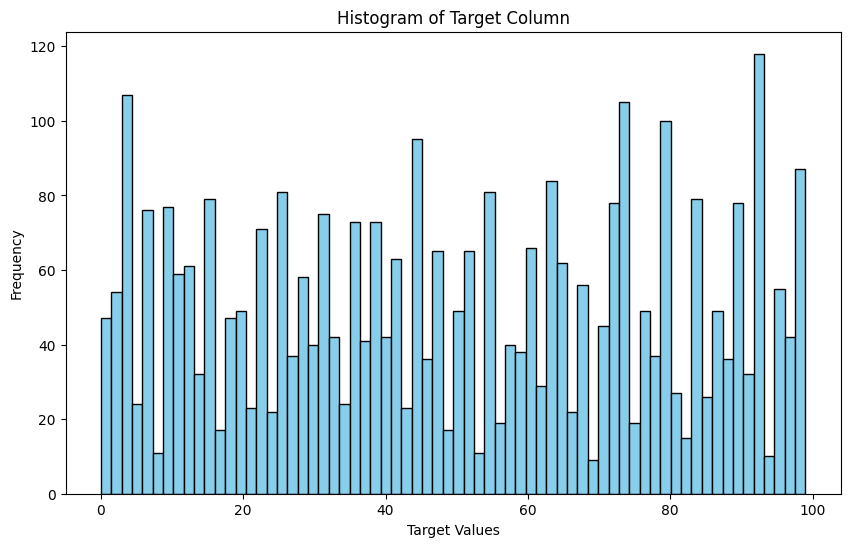

In [50]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [51]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision,decision_mode='softmax_tf')
total_train_loss,total_train_accu,sum_F,sum_T


(0.1940220799177885, 0.96265, 7697, 32303)

In [52]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision,decision_mode='softmax_tf')
total_valid_loss,total_valid_accu,sum_F,sum_T

(1.4641750673294067, 0.6547, 2167, 7833)